In [18]:
import os
from pathlib import Path

from dotenv import load_dotenv
import pandas as pd
import yaml

from src.tools.find_content import load_all_chunks_meta_fast
from src.tools.presets import get_list_of_presets
from src.tools.read.split_point.load_split_point import load_analyze_split_point_dataframes


load_dotenv()

ANALYZE_SPLIT_POINTS_DIR = Path(os.getenv("ANALYZE_SPLIT_POINTS_DIR"))
CHUNKS_DIR = Path(os.getenv("CHUNKS_DIR"))


with open("params.yaml", "r", encoding="utf-8") as f:
    params = yaml.safe_load(f)

datasets_cfg = params.get("preprocess_datasets").get("datasets")
if not datasets_cfg:
    raise ValueError("Nie znaleziono datasets_download w params.yaml")

chunking_cfg = params.get("chunking").get("methods")
if not chunking_cfg:
    raise ValueError("Nie znaleziono chunking_methods w params.yaml")

analyze_cfg = params.get("analyze_retrieval").get("methods")
if not analyze_cfg:
    raise ValueError("Nie znaleziono analyze_retrieval_methods w params.yaml")

splits = params.get("chunking").get("splits")
if not splits:
    raise ValueError("Nie znaleziono splits w params.yaml")

dataset_names, dataset_params_names = get_list_of_presets(datasets_cfg)
chunking_names, chunking_params_names = get_list_of_presets(chunking_cfg)
analyze_split_point_names, analyze_split_point_names = get_list_of_presets(analyze_cfg)

configs = []
df_time = {}

for dataset, dataset_params in zip(dataset_names, dataset_params_names):
    for chunking, chunking_params in zip(chunking_names, chunking_params_names):
        for analyze, analyze_params in zip(analyze_split_point_names, analyze_split_point_names):
            for split in splits:
                configs.append({
                    "dataset_name": dataset,
                    "dataset_params_name": dataset_params,
                    "chunking_name": chunking,
                    "chunking_params_name": chunking_params,
                    "split_name": split
                })

                chunk_time_dict = load_all_chunks_meta_fast(
                    CHUNKS_DIR / dataset / dataset_params / chunking / chunking_params / split
                )

                idx = (
                    dataset,
                    dataset_params,
                    chunking,
                    chunking_params,
                    split,
                )
                df_time[idx] = chunk_time_dict.get("total_chunking_time")

df_time = pd.DataFrame.from_dict(
    df_time,
    orient="index",
    columns=["total_chunking_time"]
)

df_time.index = pd.MultiIndex.from_tuples(
    df_time.index,
    names=[
        "dataset_name",
        "dataset_params_name",
        "chunking_name",
        "chunking_params_name",
        "split_name",
    ]
)
split_point_df = load_analyze_split_point_dataframes(ANALYZE_SPLIT_POINTS_DIR, configs)


# kolumny z max_split_span -> NaN zamień na 0
max_split_cols = [col for col in split_point_df.columns if col.endswith("max_split_span")]
split_point_df[max_split_cols] = split_point_df[max_split_cols].fillna(0)

# 2. bazowa lista do dropa
cols_to_drop = [
    "sentence_correct",
    "sentence_incorrect",
    "sentence_total",
    "total_chunks",
    "total_boundaries",
    "bpr_start",
    "bpr_end",
    "boundary_violation_count",
    "orphaned_chunks",
    "orphaned_chunk_rate"
]

# 3. automatycznie dodaj tag_*_inside/splited/total
tag_suffixes = ("_inside", "_splited", "_total", "_avg_split_span", "_max_split_span")

tag_cols = [
    col for col in split_point_df.columns
    if col.endswith(tag_suffixes)
]

cols_to_drop.extend(tag_cols)

# 4. drop (bez błędu jeśli coś nie istnieje)
split_point_df = split_point_df.drop(columns=cols_to_drop)
split_point_df = split_point_df.join(df_time)
# opcjonalnie sprawdzenie
split_point_df

h1_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                            
literaryQA   default             fixed_size    norm_token           validation                 0.915663   
                                 recursive     norm                 validation                 1.000000   

                                                                                h2_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                            
literaryQA   default             fixed_size    norm_token           validation                 0.844884   
                                 recursive     norm                 validation                 1.000000   

                                                                                h3_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                            
literaryQA   default             fixed_size    norm_token           validation                 0.860158   
                                 recursive     norm                 validation                 1.000000   

                                                                                h4_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                            
literaryQA   default             fixed_size    norm_token           validation                     0.85   
                                 recursive     norm                 validation                     1.00   

                                                                                h5_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                            
literaryQA   default             fixed_size    norm_token           validation                 0.921569   
                                 recursive     norm                 validation                 1.000000   

                                                                                h6_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                            
literaryQA   default             fixed_size    norm_token           validation                      1.0   
                                 recursive     norm                 validation                      1.0   

                                                                                p_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                           
literaryQA   default             fixed_size    norm_token           validation                0.626130   
                                 recursive     norm                 validation                0.987386   

                                                                                pre_block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                             
literaryQA   default             fixed_size    norm_token           validation                  0.666667   
                                 recursive     norm                 validation                  0.986667   

                                                                                block_integrity_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                         
literaryQA   default             fixed_size    norm_token           validation              0.631386   
                                 recursive     norm                 validation              0.987674   

                                                                                boundary_violation_rate  \
dataset_name dataset_params_name chunking_name chunking_params_name split_name                            
literaryQA   defa

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import math


def plot_metrics_subplots(df, metric_cols, ncols=2):

    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    n_metrics = len(metric_cols)
    nrows = math.ceil(n_metrics / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(6 * ncols, 4 * nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    x = np.arange(len(df))

    # kolory automatyczne z matplotlib
    colors = plt.cm.tab20(np.linspace(0, 1, len(df)))

    for ax, metric in zip(axes, metric_cols):

        for i, (label, color) in enumerate(zip(labels, colors)):
            ax.bar(
                i,
                df.iloc[i][metric],
                color=color,
                label=label if metric == metric_cols[0] else None
            )

        ax.set_title(metric)
        ax.set_ylim(0, 1)

        # ukryj x ticki
        ax.set_xticks([])

    # usuń puste subploty
    for ax in axes[n_metrics:]:
        fig.delaxes(ax)

    # wspólna legenda
    fig.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    return fig, axes

(<Figure size 1800x1600 with 11 Axes>,
 array([<Axes: title={'center': 'h1_block_integrity_rate'}>,
        <Axes: title={'center': 'h2_block_integrity_rate'}>,
        <Axes: title={'center': 'h3_block_integrity_rate'}>,
        <Axes: title={'center': 'h4_block_integrity_rate'}>,
        <Axes: title={'center': 'h5_block_integrity_rate'}>,
        <Axes: title={'center': 'h6_block_integrity_rate'}>,
        <Axes: title={'center': 'p_block_integrity_rate'}>,
        <Axes: title={'center': 'pre_block_integrity_rate'}>,
        <Axes: title={'center': 'block_integrity_rate'}>,
        <Axes: title={'center': 'boundary_violation_rate'}>,
        <Axes: title={'center': 'sentence_correct_rate'}>, <Axes: >],
       dtype=object))

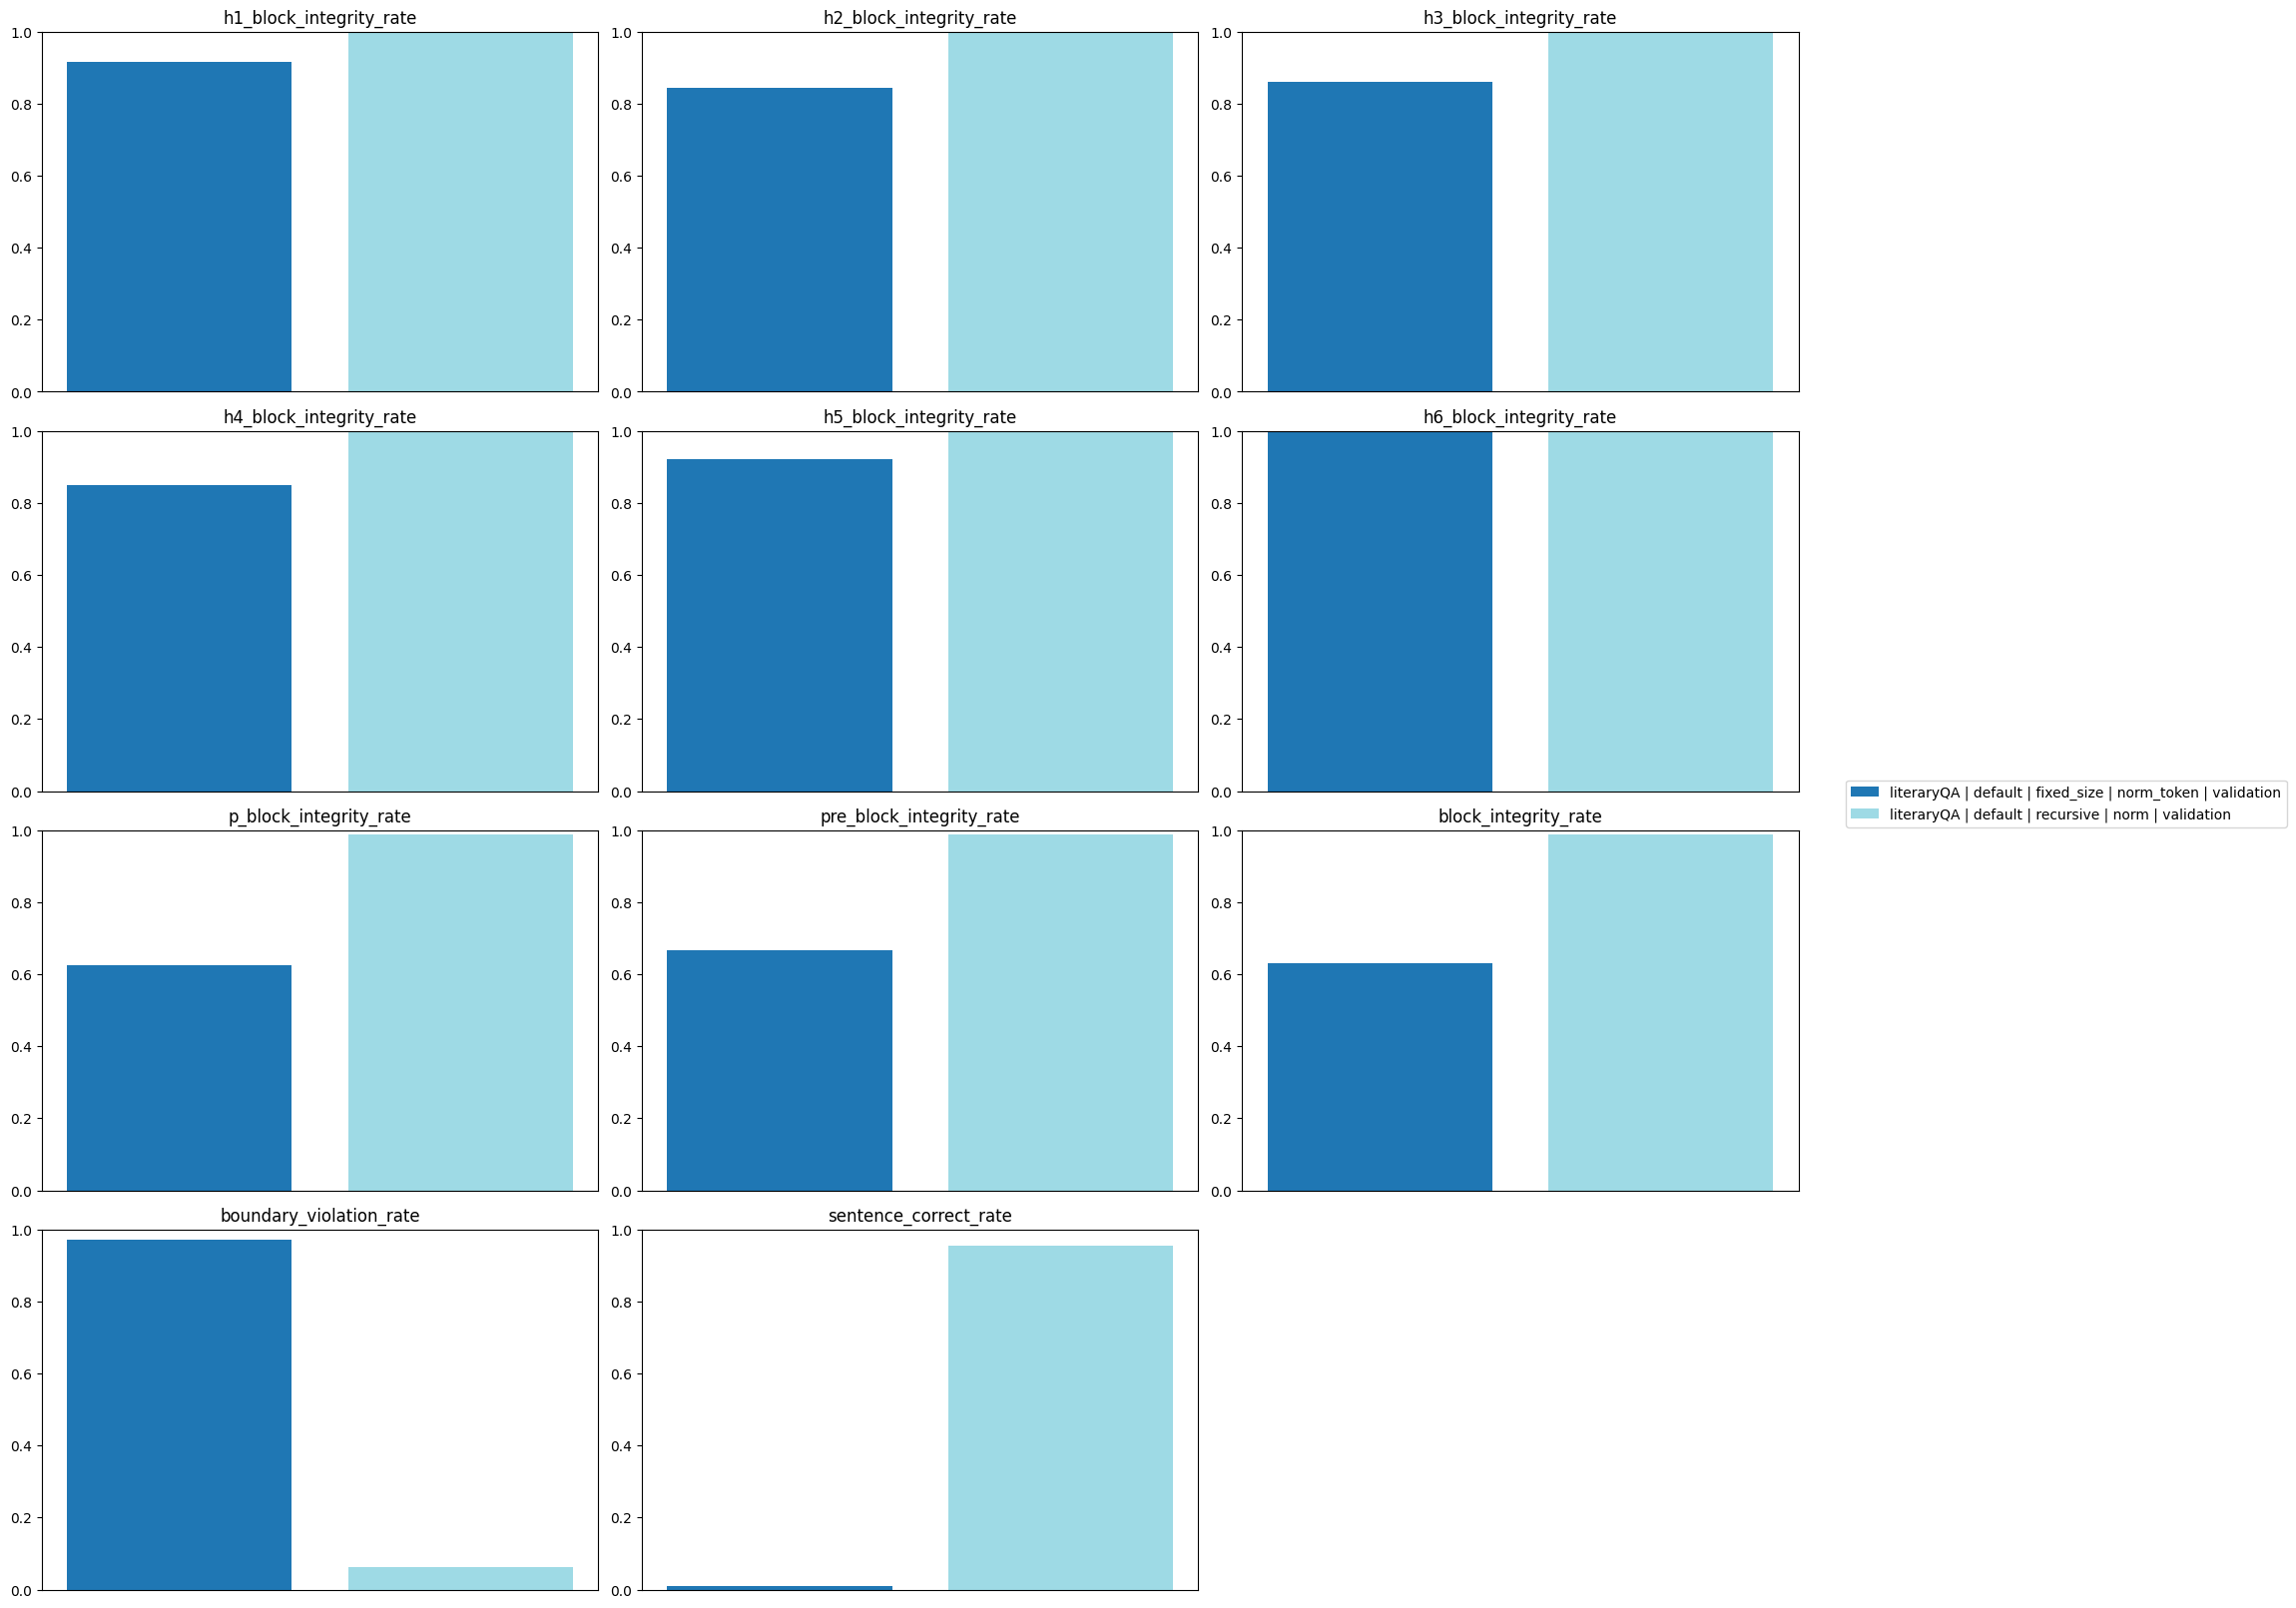

In [20]:
metric_cols = [
    "h1_block_integrity_rate",
    "h2_block_integrity_rate",
    "h3_block_integrity_rate",
    "h4_block_integrity_rate",
    "h5_block_integrity_rate",
    "h6_block_integrity_rate",
    "p_block_integrity_rate",
    "pre_block_integrity_rate",
    "block_integrity_rate",
    "boundary_violation_rate",
    "sentence_correct_rate"
]
plot_metrics_subplots(split_point_df, metric_cols, 3)

In [23]:
from matplotlib import pyplot as plt


def plot_time(df, time_column_name):
    labels = [
        " | ".join(map(str, idx))
        for idx in df.index
    ]

    fig, ax = plt.subplots(figsize=(14, 5))

    x = range(len(df))

    ax.bar(x, df[time_column_name])

    ax.set_title(time_column_name)
    ax.set_ylabel("time [s]")

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90)

    return fig, ax

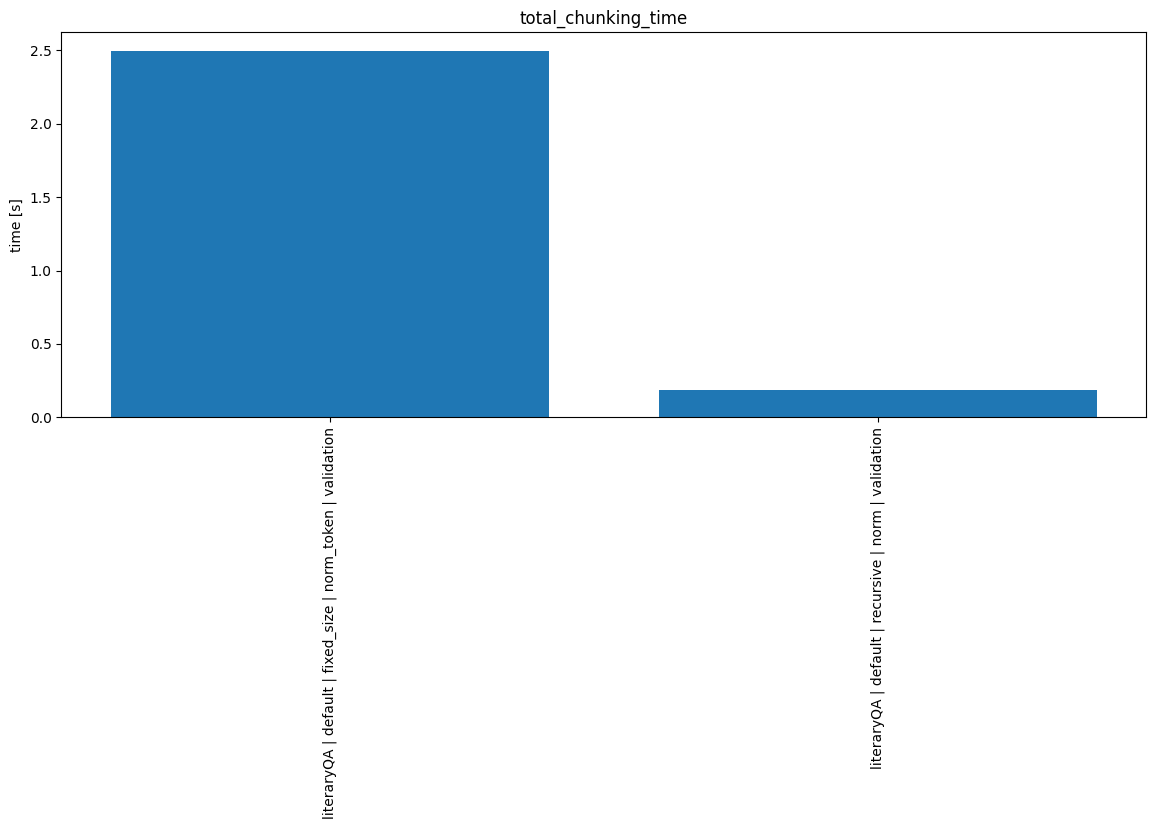

In [26]:
fig, ax = plot_time(split_point_df, 'total_chunking_time')
plt.show()